In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import simpson
from pyglam import *
import matplotlib.pyplot as plt


In [2]:
import numpy as np
from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l

def gerar_dados_e_xvals(dist="normal", size=50000):
    
    if dist == "normal":
        media, desvio = 0, 1
        x = norm.rvs(loc=media, scale=desvio, size=size)
        x_vals = np.linspace(media - 4*desvio, media + 4*desvio, 1000)

    elif dist == "triangular":
        left, mode, right = 2, 4, 6
        c = (mode - left)/(right - left)
        x = triang.rvs(c=c, loc=left, scale=right-left, size=size)
        x_vals = np.linspace(left, right, 1000)

    elif dist == "uniform":
        low, high = 2, 6
        x = uniform.rvs(loc=low, scale=high-low, size=size)
        x_vals = np.linspace(low, high, 1000)

    elif dist == "exponential":
        scale = 2
        x = expon.rvs(loc=0, scale=scale, size=size)
        x_vals = np.linspace(0, 8*scale, 1000)

    elif dist == "gumbel_r":
        loc, scale = 4, 1
        x = gumbel_r.rvs(loc=loc, scale=scale, size=size)
        x_min = gumbel_r.ppf(1e-6, loc=loc, scale=scale)
        x_max = gumbel_r.ppf(1-1e-6, loc=loc, scale=scale)
        x_vals = np.linspace(x_min, x_max, 1000)

    elif dist == "gumbel_l":
        loc, scale = 4, 1
        x = gumbel_l.rvs(loc=loc, scale=scale, size=size)
        x_min = gumbel_l.ppf(1e-6, loc=loc, scale=scale)
        x_max = gumbel_l.ppf(1-1e-6, loc=loc, scale=scale)
        x_vals = np.linspace(x_min, x_max, 1000)

    else:
        raise ValueError("Distribuição não reconhecida")

    return x, x_vals, dist

In [3]:
x, x_vals, dist_name = gerar_dados_e_xvals("normal")
# x, x_vals, dist_name = gerar_dados_e_xvals("triangular")
#x, x_vals, dist_name = gerar_dados_e_xvals("uniform")
# x, x_vals, dist_name = gerar_dados_e_xvals("exponential")
#x, x_vals, dist_name = gerar_dados_e_xvals("gumbel_r")
#x, x_vals, dist_name = gerar_dados_e_xvals("gumbel_l")

In [4]:
g = GlamFKML()
sol = g.fit_lambdas(x, method="least_squares")  # ou method="root"
print(sol.x)          # lambdas estimados
print(sol.success)    # status
print(sol.message)

[-0.00684539  1.47286979  0.13217501  0.13404897]
True
`gtol` termination condition is satisfied.


In [5]:
g = GlamFKML(*sol.x)
u_vals = np.linspace(0.001, 0.999, 500)
#rvs_glam = g.rvs(size=1000)
x_vals = g.ppf(u_vals)    ### QLD PARA OS LAMBDA ESTIMADOS   valores já ordenados, sem repetição 

mask = np.isfinite(x_vals)   #

x_vals = x_vals[mask]
pdf_glam = g.pdf(x_vals)
cdf_glam = g.cdf(x_vals)

In [7]:
from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l
from scipy.integrate import simpson
import numpy as np


# =========================
# NORMAL (média=0, desvio=1)
# =========================
p = norm.pdf(x_vals, loc=0, scale=1)

# =========================
# TRIANGULAR (left=2, mode=4, right=6)
# scipy usa parâmetro "c" = (mode - left)/(right - left)
# =========================
# c = (4 - 2) / (6 - 2)
# p = triang.pdf(x_vals, c=c, loc=2, scale=6-2)

# =========================
# UNIFORME (2, 6)
# =========================
# p = uniform.pdf(x_vals, loc=2, scale=6-2)

# =========================
# EXPONENCIAL (λ = 0.5 → scale = 1/λ = 2)
# =========================
# p = expon.pdf(x_vals, loc=0, scale=2)

# =========================
# GUMBEL DIREITA
# =========================
#p = gumbel_r.pdf(x_vals, loc=4, scale=1)

# =========================
# GUMBEL ESQUERDA
# =========================
# p = gumbel_l.pdf(x_vals, loc=4, scale=1)


# PDF aproximada (PyGLaM)
q = pdf_glam

# estabilidade numérica
eps = 1e-10
p = np.clip(p, eps, None)
q = np.clip(q, eps, None)

# KL
kl_cont = simpson(p * np.log(p / q), x_vals)

print("KL contínuo =", kl_cont)

KL contínuo = -8.761757833590565e-05


In [9]:
from scipy.stats import norm
from scipy.integrate import simpson
import numpy as np

# PDF verdadeira
p = norm.pdf(x_vals, loc=0, scale=1)

# PDF GLAM
q = pdf_glam

# estabilidade numérica
eps = 1e-10
p = np.clip(p, eps, None)
q = np.clip(q, eps, None)

# 🔥 NORMALIZAÇÃO (fundamental!)
p = p / simpson(p, x_vals)
q = q / simpson(q, x_vals)

# KL contínuo
kl_cont = simpson(p * np.log(p / q), x_vals)

# evitar negativo numérico
kl_cont = max(kl_cont, 0)

print("KL contínuo =", kl_cont)

KL contínuo = 8.55877424665024e-05


In [10]:
import numpy as np

from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l, entropy

# =========================
# NORMAL (média=0, desvio=1)
# =========================
p = norm.pdf(x_vals, loc=0, scale=1)

# =========================
# TRIANGULAR (left=2, mode=4, right=6)
# scipy usa parâmetro "c" = (mode - left)/(right - left)
# =========================
# c = (4 - 2) / (6 - 2)
# p = triang.pdf(x_vals, c=c, loc=2, scale=6-2)

# =========================
# UNIFORME (2, 6)
# =========================
# p = uniform.pdf(x_vals, loc=2, scale=6-2)

# =========================
# EXPONENCIAL (λ = 0.5 → scale = 1/λ = 2)
# =========================
# p = expon.pdf(x_vals, loc=0, scale=2)

# =========================
# GUMBEL DIREITA
# =========================
#p = gumbel_r.pdf(x_vals, loc=4, scale=1)

# =========================
# GUMBEL ESQUERDA
# =========================
# p = gumbel_l.pdf(x_vals, loc=4, scale=1)

# PDF aproximada
q = pdf_glam

# estabilidade numérica
eps = 1e-10
p = np.clip(p, eps, None)
q = np.clip(q, eps, None)

# 🔴 NORMALIZAÇÃO (essencial)
p = p / np.sum(p)
q = q / np.sum(q)

# KL divergência
kl = entropy(p, q)

print("KL =", kl)

KL = 5.19907798929443e-05


In [11]:
import numpy as np
from scipy.stats import norm
from scipy.special import rel_entr
from scipy.integrate import simpson

from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l

# =========================
# NORMAL (média=0, desvio=1)
# =========================
p = norm.pdf(x_vals, loc=0, scale=1)

# =========================
# TRIANGULAR (left=2, mode=4, right=6)
# scipy usa parâmetro "c" = (mode - left)/(right - left)
# =========================
# c = (4 - 2) / (6 - 2)
# p = triang.pdf(x_vals, c=c, loc=2, scale=6-2)

# =========================
# UNIFORME (2, 6)
# =========================
# p = uniform.pdf(x_vals, loc=2, scale=6-2)

# =========================
# EXPONENCIAL (λ = 0.5 → scale = 1/λ = 2)
# =========================
# p = expon.pdf(x_vals, loc=0, scale=2)

# =========================
# GUMBEL DIREITA
# =========================
#p = gumbel_r.pdf(x_vals, loc=4, scale=1)

# =========================
# GUMBEL ESQUERDA
# =========================
# p = gumbel_l.pdf(x_vals, loc=4, scale=1)

q = g.pdf(x_vals)

# estabilidade
eps = 1e-10
p = np.clip(p, eps, None)
q = np.clip(q, eps, None)

# 🔥 NORMALIZAÇÃO (fundamental!)
p = p / simpson(p, x_vals)
q = q / simpson(q, x_vals)


# KL com rel_entr
kl = simpson(rel_entr(p, q), x_vals)

print("KL =", kl)

KL = 8.55877424665024e-05


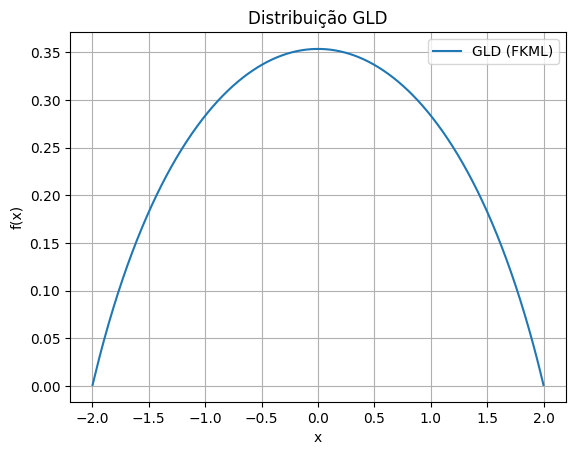

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros
l1 = 0     # localização
l2 = 1     # escala
l3 = 0.5   # forma
l4 = 0.5   # forma

# domínio (evitar 0 e 1!)
u = np.linspace(1e-6, 1 - 1e-6, 2000)

# função quantil
Q = l1 + (1/l2)*(
    (u**l3 - 1)/l3 - ((1-u)**l4 - 1)/l4
)

# derivada da quantil
dQ_du = (1/l2)*(u**(l3-1) + (1-u)**(l4-1))

# PDF
pdf = 1 / dQ_du

# ordenar (importante!)
idx = np.argsort(Q)
x = Q[idx]
pdf = pdf[idx]

# plot
plt.plot(x, pdf, label='GLD (FKML)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Distribuição GLD')
plt.legend()
plt.grid()
plt.show()

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l
from scipy.integrate import simpson

# =========================
# SUA FUNÇÃO
# =========================
def gerar_dados_e_xvals(dist="normal", size=50000):
    
    if dist == "normal":
        media, desvio = 0, 1
        x = norm.rvs(loc=media, scale=desvio, size=size)
        x_vals = np.linspace(media - 4*desvio, media + 4*desvio, 1000)

    elif dist == "triangular":
        left, mode, right = 2, 4, 6
        c = (mode - left)/(right - left)
        x = triang.rvs(c=c, loc=left, scale=right-left, size=size)
        x_vals = np.linspace(left, right, 1000)

    elif dist == "uniform":
        low, high = 2, 6
        x = uniform.rvs(loc=low, scale=high-low, size=size)
        x_vals = np.linspace(low, high, 1000)

    elif dist == "exponential":
        scale = 2
        x = expon.rvs(loc=0, scale=scale, size=size)
        x_vals = np.linspace(0, 8*scale, 1000)

    elif dist == "gumbel_r":
        loc, scale = 4, 1
        x = gumbel_r.rvs(loc=loc, scale=scale, size=size)
        x_min = gumbel_r.ppf(1e-6, loc=loc, scale=scale)
        x_max = gumbel_r.ppf(1-1e-6, loc=loc, scale=scale)
        x_vals = np.linspace(x_min, x_max, 1000)

    elif dist == "gumbel_l":
        loc, scale = 4, 1
        x = gumbel_l.rvs(loc=loc, scale=scale, size=size)
        x_min = gumbel_l.ppf(1e-6, loc=loc, scale=scale)
        x_max = gumbel_l.ppf(1-1e-6, loc=loc, scale=scale)
        x_vals = np.linspace(x_min, x_max, 1000)

    else:
        raise ValueError("Distribuição não reconhecida")

    return x, x_vals, dist


# =========================
# LISTA DE DISTRIBUIÇÕES
# =========================
dist_list = ["normal", "triangular", "uniform", "exponential", "gumbel_r", "gumbel_l"]

resultados = []

# =========================
# LOOP PRINCIPAL
# =========================
for dist in dist_list:
    
    print(f"\nProcessando: {dist}")
    
    # -------------------------
    # Dados
    # -------------------------
    x, _, dist_name = gerar_dados_e_xvals(dist)
    
    # -------------------------
    # Ajuste GLD
    # -------------------------
    g_temp = GlamFKML()
    sol = g_temp.fit_lambdas(x)
    
    if not sol.success:
        print("Falhou:", sol.message)
        continue
    
    # criar objeto GLD com parâmetros ajustados
    g = GlamFKML(*sol.x)
    
    # -------------------------
    # GRID via PPF (melhor escolha)
    # -------------------------
    u_vals = np.linspace(1e-4, 1-1e-4, 1000)
    x_vals = g.ppf(u_vals)
    
    mask = np.isfinite(x_vals)
    x_vals = x_vals[mask]
    
    # -------------------------
    # PDF GLD
    # -------------------------
    q = g.pdf(x_vals)
    
    # -------------------------
    # PDF verdadeira
    # -------------------------
    if dist_name == "normal":
        p = norm.pdf(x_vals, loc=0, scale=1)

    elif dist_name == "triangular":
        c = (4 - 2) / (6 - 2)
        p = triang.pdf(x_vals, c=c, loc=2, scale=4)

    elif dist_name == "uniform":
        p = uniform.pdf(x_vals, loc=2, scale=4)

    elif dist_name == "exponential":
        p = expon.pdf(x_vals, loc=0, scale=2)

    elif dist_name == "gumbel_r":
        p = gumbel_r.pdf(x_vals, loc=4, scale=1)

    elif dist_name == "gumbel_l":
        p = gumbel_l.pdf(x_vals, loc=4, scale=1)

    # -------------------------
    # Estabilidade numérica
    # -------------------------
    eps = 1e-12
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    
    # -------------------------
    # Normalização
    # -------------------------
    p = p / simpson(p, x_vals)
    q = q / simpson(q, x_vals)
    
    # -------------------------
    # KL divergência
    # -------------------------
    KL = simpson(p * np.log(p / q), x_vals)
    KL = max(KL, 0)
    
    resultados.append({
        "Distribuição": dist_name,
        "KL(p || GLD)": KL
    })

# =========================
# TABELA FINAL
# =========================
df = pd.DataFrame(resultados).round(6)

print("\nTabela final de KL(Simpson):")
print(df)

# opcional: exportar para LaTeX
# print(df.to_latex(index=False))


Processando: normal

Processando: triangular

Processando: uniform

Processando: exponential

Processando: gumbel_r

Processando: gumbel_l

Tabela final de KL(Simpson):
  Distribuição  KL(p || GLD)
0       normal      0.000096
1   triangular      0.006118
2      uniform      0.000093
3  exponential      0.001331
4     gumbel_r      0.002638
5     gumbel_l      0.004132


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l, entropy

# =========================
# SUA FUNÇÃO
# =========================
def gerar_dados_e_xvals(dist="normal", size=50000):
    
    if dist == "normal":
        media, desvio = 0, 1
        x = norm.rvs(loc=media, scale=desvio, size=size)

    elif dist == "triangular":
        left, mode, right = 2, 4, 6
        c = (mode - left)/(right - left)
        x = triang.rvs(c=c, loc=left, scale=right-left, size=size)

    elif dist == "uniform":
        low, high = 2, 6
        x = uniform.rvs(loc=low, scale=high-low, size=size)

    elif dist == "exponential":
        scale = 2
        x = expon.rvs(loc=0, scale=scale, size=size)

    elif dist == "gumbel_r":
        loc, scale = 4, 1
        x = gumbel_r.rvs(loc=loc, scale=scale, size=size)

    elif dist == "gumbel_l":
        loc, scale = 4, 1
        x = gumbel_l.rvs(loc=loc, scale=scale, size=size)

    else:
        raise ValueError("Distribuição não reconhecida")

    return x, dist


# =========================
# LISTA DE DISTRIBUIÇÕES
# =========================
dist_list = ["normal", "triangular", "uniform", "exponential", "gumbel_r", "gumbel_l"]

resultados = []

# =========================
# LOOP PRINCIPAL
# =========================
for dist in dist_list:
    
    print(f"\nProcessando: {dist}")
    
    # -------------------------
    # Dados
    # -------------------------
    x, dist_name = gerar_dados_e_xvals(dist)
    
    # -------------------------
    # Ajuste GLD
    # -------------------------
    g_temp = GlamFKML()
    sol = g_temp.fit_lambdas(x)
    
    if not sol.success:
        print("Falhou:", sol.message)
        continue
    
    g = GlamFKML(*sol.x)

    # -------------------------
    # GRID via PPF (não uniforme)
    # -------------------------
    u_vals = np.linspace(1e-4, 1-1e-4, 1000)
    x_vals = g.ppf(u_vals)

    mask = np.isfinite(x_vals)
    x_vals = x_vals[mask]

    # -------------------------
    # PDF GLD
    # -------------------------
    q = g.pdf(x_vals)

    # -------------------------
    # PDF verdadeira
    # -------------------------
    if dist_name == "normal":
        p = norm.pdf(x_vals, loc=0, scale=1)

    elif dist_name == "triangular":
        c = (4 - 2) / (6 - 2)
        p = triang.pdf(x_vals, c=c, loc=2, scale=4)

    elif dist_name == "uniform":
        p = uniform.pdf(x_vals, loc=2, scale=4)

    elif dist_name == "exponential":
        p = expon.pdf(x_vals, loc=0, scale=2)

    elif dist_name == "gumbel_r":
        p = gumbel_r.pdf(x_vals, loc=4, scale=1)

    elif dist_name == "gumbel_l":
        p = gumbel_l.pdf(x_vals, loc=4, scale=1)

    # -------------------------
    # Estabilidade numérica
    # -------------------------
    eps = 1e-12
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)

    # -------------------------
    # DISCRETIZAÇÃO CORRETA (com dx)
    # -------------------------
    dx = np.diff(x_vals)
    dx = np.append(dx, dx[-1])  # manter tamanho

    p_disc = p * dx
    q_disc = q * dx

    # normalizar
    p_disc /= np.sum(p_disc)
    q_disc /= np.sum(q_disc)

    # -------------------------
    # KL via entropy
    # -------------------------
    KL = entropy(p_disc, q_disc)

    resultados.append({
        "Distribuição": dist_name,
        "KL(p || GLD)": KL
    })

# =========================
# TABELA FINAL
# =========================
df = pd.DataFrame(resultados).round(6)

print("\nTabela final de KL (entropy):")
print(df)

# opcional: exportar para LaTeX
# print(df.to_latex(index=False))


Processando: normal

Processando: triangular

Processando: uniform

Processando: exponential

Processando: gumbel_r

Processando: gumbel_l

Tabela final de KL (entropy):
  Distribuição  KL(p || GLD)
0       normal      0.000091
1   triangular      0.005811
2      uniform      0.001029
3  exponential      0.001967
4     gumbel_r      0.003704
5     gumbel_l      0.004416


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l, entropy

# ==============================================================================
# FUNÇÃO AUXILIAR DE GERAÇÃO DE DADOS (Retorna 2 valores: x, dist_name)
# ==============================================================================
def gerar_dados_e_xvals(dist, n=1000):
    if dist == "normal":
        x = norm.rvs(loc=0, scale=1, size=n)
    elif dist == "triangular":
        c = (4 - 2) / (6 - 2)
        x = triang.rvs(c=c, loc=2, scale=4, size=n)
    elif dist == "uniform":
        x = uniform.rvs(loc=2, scale=4, size=n)
    elif dist == "exponential":
        x = expon.rvs(loc=0, scale=2, size=n)
    elif dist == "gumbel_r":
        x = gumbel_r.rvs(loc=4, scale=1, size=n)
    elif dist == "gumbel_l":
        x = gumbel_l.rvs(loc=4, scale=1, size=n)
    else:
        raise ValueError(f"Distribuição desconhecida: {dist}")
        
    return x, dist

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================
R = 30   # Número de simulações Monte Carlo
dist_list = ["normal", "triangular", "uniform", "exponential", "gumbel_r", "gumbel_l"]

resultados = []

# ==============================================================================
# LOOP MONTE CARLO
# ==============================================================================
for dist in dist_list:
    
    print(f"Simulando Distribuição: {dist}...")
    KL_vals = []

    for r in range(R):
        
        # -------------------------
        # Dados (Ajustado para desempacotar 2 variáveis)
        # -------------------------
        x, dist_name = gerar_dados_e_xvals(dist)

        # -------------------------
        # Ajuste GLD
        # -------------------------
        # Certifique-se de que sua classe GlamFKML está definida/importada previamente
        g_temp = GlamFKML()
        sol = g_temp.fit_lambdas(x)

        if not sol.success:
            continue

        g = GlamFKML(*sol.x)

        # -------------------------
        # Grid via PPF
        # -------------------------
        u_vals = np.linspace(1e-4, 1-1e-4, 1000)
        x_vals = g.ppf(u_vals)

        mask = np.isfinite(x_vals)
        x_vals = x_vals[mask]

        if len(x_vals) == 0:
            continue

        # -------------------------
        # PDFs
        # -------------------------
        q = g.pdf(x_vals)

        if dist_name == "normal":
            p = norm.pdf(x_vals, loc=0, scale=1)

        elif dist_name == "triangular":
            c = (4 - 2) / (6 - 2)
            p = triang.pdf(x_vals, c=c, loc=2, scale=4)

        elif dist_name == "uniform":
            p = uniform.pdf(x_vals, loc=2, scale=4)

        elif dist_name == "exponential":
            p = expon.pdf(x_vals, loc=0, scale=2)

        elif dist_name == "gumbel_r":
            p = gumbel_r.pdf(x_vals, loc=4, scale=1)

        elif dist_name == "gumbel_l":
            p = gumbel_l.pdf(x_vals, loc=4, scale=1)

        # -------------------------
        # Estabilidade Estocástica
        # -------------------------
        eps = 1e-12
        p = np.clip(p, eps, None)
        q = np.clip(q, eps, None)

        # -------------------------
        # Divergência KL
        # -------------------------
        dx = np.diff(x_vals)
        dx = np.append(dx, dx[-1])

        p_disc = p * dx
        q_disc = q * dx

        p_disc /= np.sum(p_disc)
        q_disc /= np.sum(q_disc)

        KL = entropy(p_disc, q_disc)
        KL_vals.append(KL)

    # =========================
    # Resumo das Estatísticas
    # =========================
    KL_vals = np.array(KL_vals)

    if len(KL_vals) > 0:
        resultados.append({
            "Distribuição": dist,
            "Sucessos": len(KL_vals),
            "KL médio": np.mean(KL_vals),
            "Desvio padrão": np.std(KL_vals),
            "Min": np.min(KL_vals),
            "Max": np.max(KL_vals)
        })
    else:
        resultados.append({
            "Distribuição": dist,
            "Sucessos": 0,
            "KL médio": np.nan,
            "Desvio padrão": np.nan,
            "Min": np.nan,
            "Max": np.nan
        })

# ==============================================================================
# TABELA FINAL
# ==============================================================================
df = pd.DataFrame(resultados).round(6)

print("\nTabela Monte Carlo (Divergência KL - Entropy):")
print(df.to_string(index=False))

Simulando Distribuição: normal...
Simulando Distribuição: triangular...
Simulando Distribuição: uniform...
Simulando Distribuição: exponential...
Simulando Distribuição: gumbel_r...
Simulando Distribuição: gumbel_l...

Tabela Monte Carlo (Divergência KL - Entropy):
Distribuição  Sucessos  KL médio  Desvio padrão      Min      Max
      normal        30  0.002273       0.001756 0.000087 0.008429
  triangular        30  0.007648       0.002025 0.004466 0.013301
     uniform        30  0.008593       0.005441 0.001120 0.021209
 exponential        30  0.015417       0.019920 0.000965 0.085449
    gumbel_r        30  0.008253       0.004532 0.003623 0.023009
    gumbel_l        30  0.007277       0.005490 0.002009 0.033067


In [23]:
import numpy as np
import pandas as pd
from scipy.stats import norm, triang, uniform, expon, gumbel_r, gumbel_l
from scipy.integrate import simpson

# =========================
# CONFIG
# =========================
R = 30
dist_list = ["normal", "triangular", "uniform", "exponential", "gumbel_r", "gumbel_l"]

resultados = []

# =========================
# LOOP MONTE CARLO
# =========================
for dist in dist_list:
    
    print(f"\nDistribuição: {dist}")
    KL_vals = []

    for r in range(R):
        
        # -------------------------
        # Dados
        # -------------------------
        x, dist_name = gerar_dados_e_xvals(dist)
        # -------------------------
        # Ajuste GLD
        # -------------------------
        g_temp = GlamFKML()
        sol = g_temp.fit_lambdas(x)

        if not sol.success:
            continue

        g = GlamFKML(*sol.x)

        # -------------------------
        # Grid via PPF
        # -------------------------
        u_vals = np.linspace(1e-4, 1-1e-4, 1000)
        x_vals = g.ppf(u_vals)

        mask = np.isfinite(x_vals)
        x_vals = x_vals[mask]

        # -------------------------
        # PDFs
        # -------------------------
        q = g.pdf(x_vals)

        if dist_name == "normal":
            p = norm.pdf(x_vals, loc=0, scale=1)

        elif dist_name == "triangular":
            c = (4 - 2) / (6 - 2)
            p = triang.pdf(x_vals, c=c, loc=2, scale=4)

        elif dist_name == "uniform":
            p = uniform.pdf(x_vals, loc=2, scale=4)

        elif dist_name == "exponential":
            p = expon.pdf(x_vals, loc=0, scale=2)

        elif dist_name == "gumbel_r":
            p = gumbel_r.pdf(x_vals, loc=4, scale=1)

        elif dist_name == "gumbel_l":
            p = gumbel_l.pdf(x_vals, loc=4, scale=1)

        # -------------------------
        # Estabilidade numérica
        # -------------------------
        eps = 1e-12
        p = np.clip(p, eps, None)
        q = np.clip(q, eps, None)

        # -------------------------
        # Normalização (ESSENCIAL)
        # -------------------------
        p = p / simpson(p, x_vals)
        q = q / simpson(q, x_vals)

        # -------------------------
        # KL contínuo (Simpson)
        # -------------------------
        KL = simpson(p * np.log(p / q), x_vals)
        KL = max(KL, 0)

        KL_vals.append(KL)

    # =========================
    # Estatísticas
    # =========================
    KL_vals = np.array(KL_vals)

    resultados.append({
        "Distribuição": dist,
        "KL médio": np.mean(KL_vals),
        "Desvio padrão": np.std(KL_vals),
        "Min": np.min(KL_vals),
        "Max": np.max(KL_vals)
    })

# =========================
# TABELA FINAL
# =========================
df = pd.DataFrame(resultados).round(6)

print("\nTabela Monte Carlo (KL - Simpson):")
print(df)

# opcional LaTeX
# print(df.to_latex(index=False))


Distribuição: normal

Distribuição: triangular

Distribuição: uniform

Distribuição: exponential

Distribuição: gumbel_r

Distribuição: gumbel_l

Tabela Monte Carlo (KL - Simpson):
  Distribuição  KL médio  Desvio padrão       Min       Max
0       normal  0.001471       0.000955  0.000345  0.004318
1   triangular  0.007496       0.001852  0.004534  0.011377
2      uniform  0.006333       0.005438  0.000060  0.024763
3  exponential  0.012325       0.014680  0.000851  0.046100
4     gumbel_r  0.007358       0.004064  0.002362  0.021722
5     gumbel_l  0.006685       0.004857  0.001812  0.026146


In [24]:
import numpy as np
import pandas as pd
from scipy.stats import (
    norm, triang, uniform, expon,
    gumbel_r, gumbel_l,
    beta, gamma, lognorm, weibull_min
)
from scipy.integrate import simpson

# =========================
# DISTRIBUIÇÕES
# =========================
dist_list = [
    "normal",
    "triangular",
    "uniform",
    "exponential",
    "gumbel_r",
    "gumbel_l",
    "beta",
    "gamma",
    "lognormal",
    "weibull"
]

# =========================
# GERADOR DE DADOS
# =========================
def gerar_dados(dist="normal", size=50000):
    
    if dist == "normal":
        x = norm.rvs(0, 1, size=size)

    elif dist == "triangular":
        x = triang.rvs(c=(4-2)/(6-2), loc=2, scale=4, size=size)

    elif dist == "uniform":
        x = uniform.rvs(loc=2, scale=4, size=size)

    elif dist == "exponential":
        x = expon.rvs(loc=0, scale=2, size=size)

    elif dist == "gumbel_r":
        x = gumbel_r.rvs(loc=4, scale=1, size=size)

    elif dist == "gumbel_l":
        x = gumbel_l.rvs(loc=4, scale=1, size=size)

    elif dist == "beta":
        x = beta.rvs(a=2, b=5, size=size)

    elif dist == "gamma":
        x = gamma.rvs(a=2, scale=2, size=size)

    elif dist == "lognormal":
        x = lognorm.rvs(s=0.5, scale=1, size=size)

    elif dist == "weibull":
        x = weibull_min.rvs(c=1.5, scale=2, size=size)

    else:
        raise ValueError("Distribuição não suportada")

    return x


# =========================
# MONTE CARLO CONFIG
# =========================
R = 30
resultados = []

# =========================
# LOOP PRINCIPAL
# =========================
for dist in dist_list:
    
    print(f"\nProcessando: {dist}")
    KL_vals = []

    for r in range(R):

        # -------------------------
        # dados
        # -------------------------
        x = gerar_dados(dist)

        # -------------------------
        # GLD fit
        # -------------------------
        g_temp = GlamFKML()
        sol = g_temp.fit_lambdas(x)

        if not sol.success:
            continue

        g = GlamFKML(*sol.x)

        # -------------------------
        # grid via PPF
        # -------------------------
        u_vals = np.linspace(1e-4, 1-1e-4, 1000)
        x_vals = g.ppf(u_vals)

        x_vals = x_vals[np.isfinite(x_vals)]

        # -------------------------
        # PDFs
        # -------------------------
        q = g.pdf(x_vals)

        if dist == "normal":
            p = norm.pdf(x_vals, 0, 1)

        elif dist == "triangular":
            p = triang.pdf(x_vals, c=(4-2)/4, loc=2, scale=4)

        elif dist == "uniform":
            p = uniform.pdf(x_vals, 2, 4)

        elif dist == "exponential":
            p = expon.pdf(x_vals, 0, 2)

        elif dist == "gumbel_r":
            p = gumbel_r.pdf(x_vals, 4, 1)

        elif dist == "gumbel_l":
            p = gumbel_l.pdf(x_vals, 4, 1)

        elif dist == "beta":
            p = beta.pdf(x_vals, 2, 5)

        elif dist == "gamma":
            p = gamma.pdf(x_vals, 2, scale=2)

        elif dist == "lognormal":
            p = lognorm.pdf(x_vals, 0.5, scale=1)

        elif dist == "weibull":
            p = weibull_min.pdf(x_vals, c=1.5, scale=2)

        # -------------------------
        # estabilidade
        # -------------------------
        eps = 1e-12
        p = np.clip(p, eps, None)
        q = np.clip(q, eps, None)

        # -------------------------
        # normalização correta
        # -------------------------
        p = p / simpson(p, x_vals)
        q = q / simpson(q, x_vals)

        # -------------------------
        # KL (Simpson)
        # -------------------------
        KL = simpson(p * np.log(p / q), x_vals)
        KL = max(KL, 0)

        KL_vals.append(KL)

    # -------------------------
    # estatísticas finais
    # -------------------------
    KL_vals = np.array(KL_vals)

    resultados.append({
        "Distribuição": dist,
        "KL médio": np.mean(KL_vals),
        "Desvio padrão": np.std(KL_vals),
        "Min": np.min(KL_vals),
        "Max": np.max(KL_vals)
    })

# =========================
# TABELA FINAL
# =========================
df = pd.DataFrame(resultados).round(6)

print("\nRESULTADO FINAL (KL Monte Carlo + Simpson):")
print(df)

# opcional LaTeX
# print(df.to_latex(index=False))


Processando: normal

Processando: triangular

Processando: uniform

Processando: exponential

Processando: gumbel_r

Processando: gumbel_l

Processando: beta

Processando: gamma

Processando: lognormal

Processando: weibull

RESULTADO FINAL (KL Monte Carlo + Simpson):
  Distribuição  KL médio  Desvio padrão       Min       Max
0       normal  0.000076       0.000033  0.000040  0.000182
1   triangular  0.006079       0.000147  0.005489  0.006443
2      uniform  0.001086       0.000889  0.000003  0.003069
3  exponential  0.001749       0.000428  0.000971  0.002459
4     gumbel_r  0.003229       0.000438  0.002354  0.004045
5     gumbel_l  0.003015       0.000540  0.001957  0.004039
6         beta  0.001057       0.000113  0.000822  0.001279
7        gamma  0.006233       0.000848  0.004889  0.008304
8    lognormal  0.008036       0.002801  0.003903  0.013792
9      weibull  0.001200       0.000272  0.000520  0.001661


In [28]:
import numpy as np
import pandas as pd
from scipy.stats import (
    norm, triang, uniform, expon,
    gumbel_r, gumbel_l,
    beta, gamma, lognorm, weibull_min
)
from scipy.integrate import simpson

# =========================
# DISTRIBUIÇÕES
# =========================
dist_list = [
    "normal",
    "triangular",
    "uniform",
    "exponential",
    "gumbel_r",
    "gumbel_l",
    "beta",
    "gamma",
    "lognormal",
    "weibull"
]

# =========================
# GERADOR DE DADOS
# =========================
def gerar_dados(dist="normal", size=10000):
    
    if dist == "normal":
        return norm.rvs(0, 1, size=size)

    elif dist == "triangular":
        return triang.rvs(c=(4-2)/4, loc=2, scale=4, size=size)

    elif dist == "uniform":
        return uniform.rvs(2, 4, size=size)

    elif dist == "exponential":
        return expon.rvs(0, 2, size=size)

    elif dist == "gumbel_r":
        return gumbel_r.rvs(4, 1, size=size)

    elif dist == "gumbel_l":
        return gumbel_l.rvs(4, 1, size=size)

    elif dist == "beta":
        return beta.rvs(2, 5, size=size)

    elif dist == "gamma":
        return gamma.rvs(2, scale=2, size=size)

    elif dist == "lognormal":
        return lognorm.rvs(0.5, scale=1, size=size)

    elif dist == "weibull":
        return weibull_min.rvs(1.5, scale=2, size=size)


# =========================
# CONFIG
# =========================
R = 20
resultados = []

# =========================
# LOOP PRINCIPAL
# =========================
for dist in dist_list:
    
    print(f"\nProcessando: {dist}")
    
    KL_vals = []
    KS_vals = []
    R2_vals = []

    for r in range(R):

        # -------------------------
        # dados
        # -------------------------
        x = gerar_dados(dist)

        # -------------------------
        # ajuste GLD
        # -------------------------
        g_temp = GlamFKML()
        sol = g_temp.fit_lambdas(x)

        if not sol.success:
            continue

        g = GlamFKML(*sol.x)

        # -------------------------
        # grid via PPF
        # -------------------------
        u_vals = np.linspace(1e-4, 1-1e-4, 400)
        x_vals = g.ppf(u_vals)
        x_vals = x_vals[np.isfinite(x_vals)]

        # -------------------------
        # PDF GLD
        # -------------------------
        q = g.pdf(x_vals)

        # -------------------------
        # PDF verdadeira
        # -------------------------
        if dist == "normal":
            p = norm.pdf(x_vals, 0, 1)

        elif dist == "triangular":
            p = triang.pdf(x_vals, c=(4-2)/4, loc=2, scale=4)

        elif dist == "uniform":
            p = uniform.pdf(x_vals, 2, 4)

        elif dist == "exponential":
            p = expon.pdf(x_vals, 0, 2)

        elif dist == "gumbel_r":
            p = gumbel_r.pdf(x_vals, 4, 1)

        elif dist == "gumbel_l":
            p = gumbel_l.pdf(x_vals, 4, 1)

        elif dist == "beta":
            p = beta.pdf(x_vals, 2, 5)

        elif dist == "gamma":
            p = gamma.pdf(x_vals, 2, scale=2)

        elif dist == "lognormal":
            p = lognorm.pdf(x_vals, 0.5, scale=1)

        elif dist == "weibull":
            p = weibull_min.pdf(x_vals, 1.5, scale=2)

        # -------------------------
        # estabilidade
        # -------------------------
        eps = 1e-12
        p = np.clip(p, eps, None)
        q = np.clip(q, eps, None)

        # -------------------------
        # normalização
        # -------------------------
        p = p / simpson(p, x_vals)
        q = q / simpson(q, x_vals)

        # -------------------------
        # KL (Simpson)
        # -------------------------
        KL = simpson(p * np.log(p / q), x_vals)
        KL = max(KL, 0)

        # -------------------------
        # KS correto (ECDF vs ECDF simulada)
        # -------------------------
        x_sorted = np.sort(x)
        x_model = g.rvs(size=len(x))
        x_model_sorted = np.sort(x_model)

        n = len(x_sorted)

        x_all = np.sort(np.concatenate([x_sorted, x_model_sorted]))

        cdf_emp = np.searchsorted(x_sorted, x_all, side='right') / n
        cdf_model = np.searchsorted(x_model_sorted, x_all, side='right') / n

        KS = np.max(np.abs(cdf_emp - cdf_model))

        # -------------------------
        # R² (corrigido)
        # -------------------------
        ss_res = np.sum((p - q)**2)
        ss_tot = np.sum((p - np.mean(p))**2)

        if ss_tot < 1e-14:
            R2 = np.nan
        else:
            R2 = 1 - ss_res / ss_tot
            R2 = np.clip(R2, -1, 1)

        # -------------------------
        # armazenar
        # -------------------------
        KL_vals.append(KL)
        KS_vals.append(KS)
        R2_vals.append(R2)

    # -------------------------
    # estatísticas finais
    # -------------------------
    resultados.append({
        "Distribuição": dist,
        "KL médio": np.nanmean(KL_vals),
        "KL std": np.nanstd(KL_vals),
        "KS médio": np.nanmean(KS_vals),
        "KS std": np.nanstd(KS_vals),
        "R² médio": np.nanmean(R2_vals),
        "R² std": np.nanstd(R2_vals),
    })

# =========================
# RESULTADO FINAL
# =========================
df = pd.DataFrame(resultados).round(6)

print("\nRESULTADO FINAL (DEFINITIVO):")
print(df)

# opcional
# print(df.to_latex(index=False))


Processando: normal

Processando: triangular

Processando: uniform

Processando: exponential

Processando: gumbel_r

Processando: gumbel_l

Processando: beta

Processando: gamma

Processando: lognormal

Processando: weibull

RESULTADO FINAL (DEFINITIVO):
  Distribuição  KL médio    KL std  KS médio    KS std  R² médio    R² std
0       normal  0.000247  0.000166  0.006255  0.001085  0.998905  0.001520
1   triangular  0.003498  0.000618  0.011575  0.001323  0.966192  0.003709
2      uniform  0.002731  0.002733  0.005070  0.001253  0.028985  0.300550
3  exponential  0.003622  0.008048  0.022800  0.009602  0.946401  0.100803
4     gumbel_r  0.004213  0.001221  0.016105  0.004277  0.969139  0.013314
5     gumbel_l  0.004370  0.001749  0.018485  0.015345  0.970932  0.012235
6         beta  0.001298  0.000211  0.008200  0.001715  0.990217  0.004142
7        gamma  0.005792  0.002715  0.026065  0.008769  0.884253  0.084419
8    lognormal  0.010521  0.005770  0.032505  0.013331  0.819966  0.1

## KS   KL  wasserstein_distance

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import (
    norm, triang, uniform, expon,
    gumbel_r, gumbel_l,
    beta, gamma, lognorm, weibull_min,
    wasserstein_distance  # <-- IMPORTADO AQUI
)
from scipy.integrate import simpson

# =========================
# DISTRIBUIÇÕES
# =========================
dist_list = [
    "normal",
    "triangular",
    "uniform",
    "exponential",
    "gumbel_r",
    "gumbel_l",
    "beta",
    "gamma",
    "lognormal",
    "weibull"
]

# =========================
# GERADOR DE DADOS
# =========================
def gerar_dados(dist="normal", size=10000):
    if dist == "normal":
        return norm.rvs(0, 1, size=size)
    elif dist == "triangular":
        return triang.rvs(c=(4-2)/4, loc=2, scale=4, size=size)
    elif dist == "uniform":
        return uniform.rvs(2, 4, size=size)
    elif dist == "exponential":
        return expon.rvs(0, 2, size=size)
    elif dist == "gumbel_r":
        return gumbel_r.rvs(4, 1, size=size)
    elif dist == "gumbel_l":
        return gumbel_l.rvs(4, 1, size=size)
    elif dist == "beta":
        return beta.rvs(2, 5, size=size)
    elif dist == "gamma":
        return gamma.rvs(2, scale=2, size=size)
    elif dist == "lognormal":
        return lognorm.rvs(0.5, scale=1, size=size)
    elif dist == "weibull":
        return weibull_min.rvs(1.5, scale=2, size=size)

# =========================
# CONFIG
# =========================
R = 20
resultados = []

# =========================
# LOOP PRINCIPAL
# =========================
for dist in dist_list:
    
    print(f"\nProcessando: {dist}")
    
    KL_vals = []
    KS_vals = []
    R2_vals = []
    W1_vals = []  # <-- LISTA CRIADA

    for r in range(R):

        # -------------------------
        # dados
        # -------------------------
        x = gerar_dados(dist)

        # -------------------------
        # ajuste GLD
        # -------------------------
        g_temp = GlamFKML()
        sol = g_temp.fit_lambdas(x)

        if not sol.success:
            continue

        g = GlamFKML(*sol.x)

        # -------------------------
        # grid via PPF
        # -------------------------
        u_vals = np.linspace(1e-4, 1-1e-4, 400)
        x_vals = g.ppf(u_vals)
        x_vals = x_vals[np.isfinite(x_vals)]

        # -------------------------
        # PDF GLD
        # -------------------------
        q = g.pdf(x_vals)

        # -------------------------
        # PDF verdadeira
        # -------------------------
        if dist == "normal":
            p = norm.pdf(x_vals, 0, 1)
        elif dist == "triangular":
            p = triang.pdf(x_vals, c=(4-2)/4, loc=2, scale=4)
        elif dist == "uniform":
            p = uniform.pdf(x_vals, 2, 4)
        elif dist == "exponential":
            p = expon.pdf(x_vals, 0, 2)
        elif dist == "gumbel_r":
            p = gumbel_r.pdf(x_vals, 4, 1)
        elif dist == "gumbel_l":
            p = gumbel_l.pdf(x_vals, 4, 1)
        elif dist == "beta":
            p = beta.pdf(x_vals, 2, 5)
        elif dist == "gamma":
            p = gamma.pdf(x_vals, 2, scale=2)
        elif dist == "lognormal":
            p = lognorm.pdf(x_vals, 0.5, scale=1)
        elif dist == "weibull":
            p = weibull_min.pdf(x_vals, 1.5, scale=2)

        # -------------------------
        # estabilidade
        # -------------------------
        eps = 1e-12
        p = np.clip(p, eps, None)
        q = np.clip(q, eps, None)

        # -------------------------
        # normalização
        # -------------------------
        p = p / simpson(p, x_vals)
        q = q / simpson(q, x_vals)

        # -------------------------
        # KL (Simpson)
        # -------------------------
        KL = simpson(p * np.log(p / q), x_vals)
        KL = max(KL, 0)

        # -------------------------
        # KS correto (ECDF vs ECDF simulada)
        # -------------------------
        x_sorted = np.sort(x)
        x_model = g.rvs(size=len(x))
        x_model_sorted = np.sort(x_model)

        n = len(x_sorted)

        x_all = np.sort(np.concatenate([x_sorted, x_model_sorted]))

        cdf_emp = np.searchsorted(x_sorted, x_all, side='right') / n
        cdf_model = np.searchsorted(x_model_sorted, x_all, side='right') / n

        KS = np.max(np.abs(cdf_emp - cdf_model))

        # -------------------------
        # Wasserstein Distance
        # -------------------------
        W1 = wasserstein_distance(x, x_model)  # <-- CÁLCULO AQUI

        # -------------------------
        # R² (corrigido)
        # -------------------------
        ss_res = np.sum((p - q)**2)
        ss_tot = np.sum((p - np.mean(p))**2)

        if ss_tot < 1e-14:
            R2 = np.nan
        else:
            R2 = 1 - ss_res / ss_tot
            R2 = np.clip(R2, -1, 1)

        # -------------------------
        # armazenar
        # -------------------------
        KL_vals.append(KL)
        KS_vals.append(KS)
        W1_vals.append(W1)  # <-- ARMAZENADO AQUI
        R2_vals.append(R2)

    # -------------------------
    # estatísticas finais
    # -------------------------
    resultados.append({
        "Distribuição": dist,
        "KL médio": np.nanmean(KL_vals),
        "KL std": np.nanstd(KL_vals),
        "KS médio": np.nanmean(KS_vals),
        "KS std": np.nanstd(KS_vals),
        "W1 médio": np.nanmean(W1_vals),  # <-- EXIBIÇÃO NO DATAFRAME
        "W1 std": np.nanstd(W1_vals),      # <-- EXIBIÇÃO NO DATAFRAME
        "R² médio": np.nanmean(R2_vals),
        "R² std": np.nanstd(R2_vals),
    })

# =========================
# RESULTADO FINAL
# =========================
df = pd.DataFrame(resultados).round(6)

print("\nRESULTADO FINAL (DEFINITIVO):")
print(df)


Processando: normal

Processando: triangular

Processando: uniform

Processando: exponential

Processando: gumbel_r

Processando: gumbel_l

Processando: beta

Processando: gamma

Processando: lognormal

Processando: weibull

RESULTADO FINAL (DEFINITIVO):
  Distribuição  KL médio    KL std  KS médio    KS std  W1 médio    W1 std  \
0       normal  0.000191  0.000095  0.006040  0.001090  0.009366  0.001210   
1   triangular  0.003235  0.000276  0.011235  0.001731  0.015231  0.002047   
2      uniform  0.003051  0.003210  0.005880  0.001163  0.006517  0.001727   
3  exponential  0.005078  0.009619  0.024670  0.009747  0.036609  0.010935   
4     gumbel_r  0.003904  0.001130  0.014995  0.003024  0.031134  0.005901   
5     gumbel_l  0.004099  0.001246  0.015280  0.003477  0.032058  0.006518   
6         beta  0.001368  0.000231  0.007965  0.001494  0.001821  0.000420   
7        gamma  0.006106  0.002555  0.026570  0.008771  0.062644  0.014157   
8    lognormal  0.009973  0.004570  0.0340

##   Com erro relativo para os percentis

In [30]:
import numpy as np
import pandas as pd
from scipy.stats import (
    norm, triang, uniform, expon,
    gumbel_r, gumbel_l,
    beta, gamma, lognorm, weibull_min,
    wasserstein_distance
)
from scipy.integrate import simpson

# =========================
# DISTRIBUIÇÕES
# =========================
dist_list = [
    "normal",
    "triangular",
    "uniform",
    "exponential",
    "gumbel_r",
    "gumbel_l",
    "beta",
    "gamma",
    "lognorm",
    "weibull"
]

# =========================
# GERADOR DE DADOS
# =========================
def gerar_dados(dist="normal", size=10000):
    if dist == "normal":
        return norm.rvs(0, 1, size=size)
    elif dist == "triangular":
        return triang.rvs(c=(4-2)/4, loc=2, scale=4, size=size)
    elif dist == "uniform":
        return uniform.rvs(2, 4, size=size)
    elif dist == "exponential":
        return expon.rvs(0, 2, size=size)
    elif dist == "gumbel_r":
        return gumbel_r.rvs(4, 1, size=size)
    elif dist == "gumbel_l":
        return gumbel_l.rvs(4, 1, size=size)
    elif dist == "beta":
        return beta.rvs(2, 5, size=size)
    elif dist == "gamma":
        return gamma.rvs(2, scale=2, size=size)
    elif dist == "lognorm":
        return lognorm.rvs(0.5, scale=1, size=size)
    elif dist == "weibull":
        return weibull_min.rvs(1.5, scale=2, size=size)

# =========================
# CONFIG
# =========================
R = 20
resultados = []

# =========================
# LOOP PRINCIPAL
# =========================
for dist in dist_list:
    
    print(f"\nProcessando: {dist}")
    
    KL_vals, KS_vals, R2_vals, W1_vals = [], [], [], []
    er_p5_vals, er_p50_vals, er_p95_vals = [], [], [] # <-- NOVAS LISTAS

    for r in range(R):

        # dados
        x = gerar_dados(dist)

        # ajuste GLD
        g_temp = GlamFKML()
        sol = g_temp.fit_lambdas(x)

        if not sol.success:
            continue

        g = GlamFKML(*sol.x)

        # grid via PPF
        u_vals = np.linspace(1e-4, 1-1e-4, 400)
        x_vals = g.ppf(u_vals)
        x_vals = x_vals[np.isfinite(x_vals)]

        # PDF GLD
        q = g.pdf(x_vals)

        # PDF verdadeira
        if dist == "normal": p = norm.pdf(x_vals, 0, 1)
        elif dist == "triangular": p = triang.pdf(x_vals, c=(4-2)/4, loc=2, scale=4)
        elif dist == "uniform": p = uniform.pdf(x_vals, 2, 4)
        elif dist == "exponential": p = expon.pdf(x_vals, 0, 2)
        elif dist == "gumbel_r": p = gumbel_r.pdf(x_vals, 4, 1)
        elif dist == "gumbel_l": p = gumbel_l.pdf(x_vals, 4, 1)
        elif dist == "beta": p = beta.pdf(x_vals, 2, 5)
        elif dist == "gamma": p = gamma.pdf(x_vals, 2, scale=2)
        elif dist == "lognorm": p = lognorm.pdf(x_vals, 0.5, scale=1)
        elif dist == "weibull": p = weibull_min.pdf(x_vals, 1.5, scale=2)

        eps = 1e-12
        p = np.clip(p, eps, None)
        q = np.clip(q, eps, None)

        p = p / simpson(p, x_vals)
        q = q / simpson(q, x_vals)

        # KL
        KL = max(simpson(p * np.log(p / q), x_vals), 0)

        # Amostragem do modelo
        x_sorted = np.sort(x)
        x_model = g.rvs(size=len(x))
        x_model_sorted = np.sort(x_model)

        # KS
        n = len(x_sorted)
        x_all = np.sort(np.concatenate([x_sorted, x_model_sorted]))
        cdf_emp = np.searchsorted(x_sorted, x_all, side='right') / n
        cdf_model = np.searchsorted(x_model_sorted, x_all, side='right') / n
        KS = np.max(np.abs(cdf_emp - cdf_model))

        # Wasserstein
        W1 = wasserstein_distance(x, x_model)

        # R²
        ss_res = np.sum((p - q)**2)
        ss_tot = np.sum((p - np.mean(p))**2)
        R2 = np.nan if ss_tot < 1e-14 else np.clip(1 - ss_res / ss_tot, -1, 1)

        # ---------------------------------------------------------
        # CÁLCULO DOS ERROS RELATIVOS NOS QUANTIS P5, P50 E P95
        # ---------------------------------------------------------
        p5_real, p50_real, p95_real = np.percentile(x, [5, 50, 95])
        p5_mod, p50_mod, p95_mod = np.percentile(x_model, [5, 50, 95])

        # Função auxiliar para evitar divisão por zero (ex: mediana da Normal = 0)
        def erro_relativo(mod, real, tol=1e-5):
            if abs(real) < tol:
                return mod - real  # Erro absoluto se a referência for próxima de zero
            return (mod - real) / abs(real)

        er_p5 = erro_relativo(p5_mod, p5_real)
        er_p50 = erro_relativo(p50_mod, p50_real)
        er_p95 = erro_relativo(p95_mod, p95_real)

        # Armazenar
        KL_vals.append(KL)
        KS_vals.append(KS)
        W1_vals.append(W1)
        R2_vals.append(R2)
        er_p5_vals.append(er_p5)
        er_p50_vals.append(er_p50)
        er_p95_vals.append(er_p95)

    # -------------------------
    # estatísticas finais
    # -------------------------
    resultados.append({
        "Distribuição": dist,
        "KL médio": np.nanmean(KL_vals),
        "KS médio": np.nanmean(KS_vals),
        "W1 médio": np.nanmean(W1_vals),
        "R² médio": np.nanmean(R2_vals),
        "ER_P5 médio": np.nanmean(er_p5_vals),    # <-- NOVO
        "ER_P50 médio": np.nanmean(er_p50_vals),  # <-- NOVO
        "ER_P95 médio": np.nanmean(er_p95_vals),  # <-- NOVO
    })

# =========================
# RESULTADO FINAL
# =========================
df = pd.DataFrame(resultados).round(6)

print("\nRESULTADO FINAL (DEFINITIVO):")
print(df)


Processando: normal

Processando: triangular

Processando: uniform

Processando: exponential

Processando: gumbel_r

Processando: gumbel_l

Processando: beta

Processando: gamma

Processando: lognorm

Processando: weibull

RESULTADO FINAL (DEFINITIVO):
  Distribuição  KL médio  KS médio  W1 médio  R² médio  ER_P5 médio  \
0       normal  0.000275  0.006115  0.009396  0.998691     0.002835   
1   triangular  0.003239  0.012340  0.016364  0.966298     0.011160   
2      uniform  0.003659  0.005490  0.006089  0.022736     0.003037   
3  exponential  0.001532  0.021365  0.031755  0.976678     0.291392   
4     gumbel_r  0.004023  0.014575  0.031493  0.972352     0.003646   
5     gumbel_l  0.003818  0.013835  0.030012  0.975512     0.036192   
6         beta  0.001407  0.008090  0.001874  0.988455     0.018030   
7        gamma  0.006625  0.028295  0.062365  0.862370     0.117655   
8      lognorm  0.010866  0.034500  0.019343  0.814800     0.060829   
9      weibull  0.001799  0.013425  